In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# numpy array
import numpy as np
array =[[1,2,3], [1,2,3]]
first_array = np.array(array)
print("array type: {}".format(type(first_array)))
print("array shape: {}".format(np.shape(first_array)))
print(first_array)

array type: <class 'numpy.ndarray'>
array shape: (2, 3)
[[1 2 3]
 [1 2 3]]


In [3]:
# torch tensor
import torch
tensor = torch.tensor(first_array)
print("array type: {}".format(type(tensor)))
print("array shape: {}".format(tensor.shape))
# print("array shape: {}".format(np.shape(tensor)) 과 동일
print(tensor)

array type: <class 'torch.Tensor'>
array shape: torch.Size([2, 3])
tensor([[1, 2, 3],
        [1, 2, 3]])


In [8]:
# np.ones
np_ones = np.ones((2,3)) #np.ones(*array_shape*)
print(np_ones)

# torch.ones
torch_ones = torch.ones((2,3))
print(torch_ones)

[[1. 1. 1.]
 [1. 1. 1.]]
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [12]:
# numpy.random.rand
np_random = np.random.rand(2,3)
print(np_random)

# torch.rand
torch_random = torch.rand(2,3)
print(torch_random)

[[3.44071347e-04 5.85990041e-05 4.60545174e-01]
 [4.72718962e-01 5.52925752e-01 6.22564640e-01]]
tensor([[0.7607, 0.6825, 0.3936],
        [0.2205, 0.2964, 0.1119]])


In [19]:
array = np.random.rand(2,2)

# from numpy to tensor
from_numpy_to_tensor = torch.from_numpy(array) # 이렇게 하면 numpy랑 tensor가 메모리 공유
to_tensor = torch.tensor(array) # 이렇게 하면 copy 해서 사용
print(from_numpy_to_tensor)
print(to_tensor)

# from tensor to numpy
tensor = from_numpy_to_tensor
from_tensor_to_numpy = tensor.numpy() # 이렇게 하면 tensor랑 numpy랑 메모리 공유
to_numpy = np.array(tensor) # 이렇게 하면 copy해서 사용
print(from_tensor_to_numpy)
print(to_numpy)


tensor([[0.3873, 0.4447],
        [0.3241, 0.9332]], dtype=torch.float64)
tensor([[0.3873, 0.4447],
        [0.3241, 0.9332]], dtype=torch.float64)
[[0.38726549 0.44470869]
 [0.32414481 0.9332065 ]]
[[0.38726549 0.44470869]
 [0.32414481 0.9332065 ]]


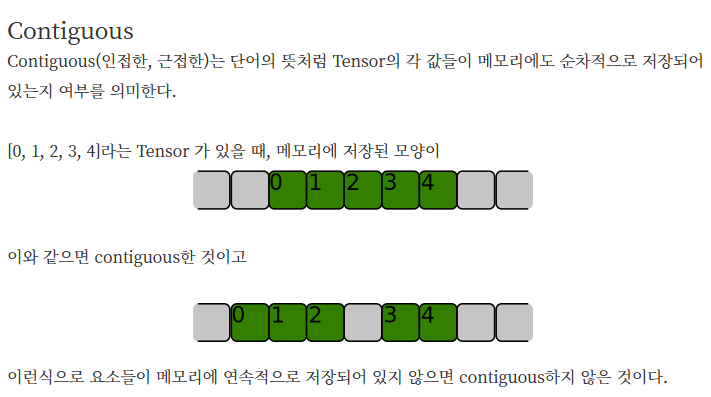

In [36]:
# reshape

# create tensor
tensor = torch.arange(1,13)
print("\n", tensor)

# resize
print("{}\n{}".format(tensor.view(12).shape, tensor.view(12))) # 1차원
print("{}\n{}".format(tensor.view(1,12).shape, tensor.view(1,12))) # 2차원
print("{}\n{}".format(tensor.view(2,6).shape, tensor.view(2,6)))

tensor1 = tensor.view(2,6)
transpose_tensor = tensor1.transpose(0,1)
print("transpose_tensor.shape: {}\n".format(transpose_tensor.shape))
#print("{}\n{}".format(transpose_tensor.view(3,4).shape, transpose_tensor.view(3,4)))

# RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces)
# 위 에러가 뜨는 이유는 transpose 시에 메모리 위치가 바뀌어 uncontiguous 해져서 view를 사용하지 못함. 
# 아래가 문제에 대한 해결 코드: contiguous() 함수 사용
print("{}\n{}".format(transpose_tensor.contiguous().view(3,4).shape, transpose_tensor.contiguous().view(3,4)))



 tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
torch.Size([12])
tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
torch.Size([1, 12])
tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]])
torch.Size([2, 6])
tensor([[ 1,  2,  3,  4,  5,  6],
        [ 7,  8,  9, 10, 11, 12]])
transpose_tensor.shape: torch.Size([6, 2])

torch.Size([3, 4])
tensor([[ 1,  7,  2,  8],
        [ 3,  9,  4, 10],
        [ 5, 11,  6, 12]])


In [42]:
from torch.autograd import Variable
# basic back propagation
var = Variable(torch.ones(3), requires_grad = True)
var


tensor([1., 1., 1.], requires_grad=True)

In [46]:
array = [2,4]
tensor = torch.Tensor(array)
x = Variable(tensor, requires_grad = True)
y = x**2
print("y = ", y)
o = (1/2)*sum(y)
print("o = ", o)
o.backward()
print("gradients: ", x.grad)

y =  tensor([ 4., 16.], grad_fn=<PowBackward0>)
o =  tensor(10., grad_fn=<MulBackward0>)
gradients:  tensor([2., 4.])


# Training CNN

#### steps of CNN:
1. import libraries
2. prepare dataset
3. conv layer
4. pooling layer
5. Flattening
6. Fully Connected Layer
7. Initiate Model Class
8. Initiate Loss
9. Initiate Optimizer
10. Training the Model
11. Prediction

In [47]:
# 1. import libraries
import torch
from torch.autograd import Variable
import torch.nn as nn 
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import torchvision
import torchvision.transforms as transforms

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # conv 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()

        # maxpool 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # conv 2
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()

        # maxpool 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # fc
        self.fc = nn.Linear(32*4*4, 10)
    
    def forward(self,x):
        # conv 1
        out = self.cnn1(x)
        out = self.relu1(out)

        # maxpool 1
        out = self.maxpool1(out)

        # conv 2
        out = self.cnn2(x)
        out = self.relu2(out)

        # maxpool 2
        out = self.maxpool2(out)

        # fc
        out = self.fc(out)

        return out

# batch_size, epoch and iteration
batch_size = 100 # 하나의 배치에 들어있는 샘플 수
n_iters = 2500
num_epochs = n_iters/(len(data)/batch_size) # epoch = data 나누기 batch_size
num_epochs = int(num_epochs)

transform = transforms.Compose(
    [transforms.toTensor(),
     transforms.resize(224,224),
     transforms.normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_loader =DataLoader(test, shuffle=False)

model = CNNModel()
loss = nn.CrossEntropyLoss()

# optimizer
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
count = 0
loss_list = []
iteration_list = []
accuray_list = []

for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        # clear optimizer
        optimizer.zero_grad()

        # forward pass
        outputs = model(train)

        # calculate softmax and ross entropy loss
        loss = loss(outputs, labels)

        # calculate gradient
        loss.backward()

        # update parameters
        optimizer.step()

        count += 1

        if count % 50 == 0:
            correct = 0
            total = 0

            for images, labels in test_loader:

                test = Variable(images.view(100, 1, 28, 28))

                # forward pass
                outputs = model(test)

                # get predictions from the maximum value
                predicted = torch.max(outputs.data, 1)[1]

                total += len(labels)

                correct += (predicted == labels).sum()

            accuracy = 100*correct / float(total)